# Notebook Outline

1. Description and context of the dataset 
2. 1D stimulus: identification of simple and complex cells, analysis of the stimulus, STA, linear kernel, STC, static non-linearity, evaluation
3. 2D stimulus: analysis of the stimulus, comparison of firing rates, STA, predictive models

# 1. Dataset Provenance and Scientific Context

The CRCNS PVC-2 dataset used in this notebook contains extracellular spike recordings from neurons in the **primary visual cortex (V1) of anesthetized cats**, collected in the laboratory of **Yang Dan (UC Berkeley)**. These recordings were used in influential studies on how cortical neurons encode visual stimuli.

Two key publications based on this dataset are:

#### 1. Touryan, Lau & Dan (2002) — *Isolation of relevant visual features from random stimuli for cortical complex cells*  
**Journal of Neuroscience, 22, 10811–10818**

This study used random stimulus ensembles and spike-triggered covariance methods to identify the stimulus features that drive **complex cells** in V1. It demonstrated that nonlinear receptive field components of cortical neurons can be recovered directly from spike responses.

#### 2. Touryan, Felsen & Dan (2005) — *Spatial Structure of Complex Cell Receptive Fields Measured with Natural Images*  
**Neuron, 45, 781–791**

This later work extended the analysis to **natural image stimuli**, showing that complex-cell receptive fields can be described by a small number of oriented subunits. The results supported the classical **energy model** of visual cortical processing and provided an early example of nonlinear neural encoding under naturalistic stimulation.

## structure of the dataset
Based on archived correspondence from the original investigators, filenames encode:

YYMMDD.(chamber).(penetration)(cell number)(run number)(stimulus).(filetype)

Thus files such as `000413.b03bmsq1D.sa0`, `000413.b03cmsq1D.sa0`, and `000413.b03dmsq1D.sa0` correspond to the same recorded unit (`b03`) across different sequential runs (`b`, `c`, `d`) using the `msq1D` stimulus.



## settings for the project

In [97]:
# part 1
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
import sys
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

# part 2
import scipy.io as sio 
import time
from IPython import display

In [68]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


DATA_ROOT=PROJECT_ROOT/'data'/'crcns-pvc2'
root =DATA_ROOT / "1D_white_noise/Spike_and_Log_Files"



from src.get_spikes import (fget_spk_python, retrieve_log, tori,
                            load_log_lines, numbers,
                            search_log)




In [69]:
def is_it_complex(directory, plot=False):

    ''' defines if the neuron in the folder us complex or simple'''

    results={}
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)

        
        
        tune_logs = [
            f for f in os.listdir(folder_path)
            if f.endswith("tune.log")
        ]

        first_file = sorted(tune_logs)[0]

        
        
        flog = retrieve_log(
        path=directory/folder,
        filename=first_file,
        channels=None
    )

        info = tori(flog, cluster_index=0, plot=plot)

        relmod = info["relmod"]

        if relmod > 1.0:
            cell_type = "simple / linear-like"
        else:
            cell_type = "complex / nonlinear-like"

        results[folder] = {
            "file": first_file,
            "relmod": relmod,
            "cell_type": cell_type,
            
        }

    return results

In [70]:
cell_results = is_it_complex(root, plot=False)
simple_cells = {
    folder: result
    for folder, result in cell_results.items()
    if result["cell_type"] == "simple / linear-like"
}
simple_cells


Correcting spike file: 000512.d11atune.sa0 -> 000513.d11atune.sa0
Correcting spike file: 000802.c05atune.sa1 -> 000802.c05atune.sa0


{'000420.b02': {'file': '000420.b02atune.log',
  'relmod': np.float64(1.8052012990662303),
  'cell_type': 'simple / linear-like'},
 '010801.A.b01': {'file': '010801.A.b01dtune.log',
  'relmod': np.float64(1.1081355156101487),
  'cell_type': 'simple / linear-like'}}

In [71]:
COMPLEX_NEURON_PATH= root/'000413.b03'

LINEAR_NEURON_PATH_1 =root/'010801.A.b01'
LINEAR_NEURON_PATH_2 =root/'000420.b02'

STIM_PATH  = DATA_ROOT/'1D_white_noise/Stimulus_Files/msq1D.mat'

ISTIM_PATH = DATA_ROOT/'1D_white_noise/Stimulus_Files/imsq1D.mat'


filenames_complex = [
    
    '000413.b03bmsq1D.sa0',
    '000413.b03cmsq1D.sa0',
    '000413.b03dmsq1D.sa0',
    '000413.b03fmsq1D.sa0',
    '000413.b03hmsq1D.sa0',
]

filenames_linear_1 = [
    "010801.A.b01emsq1D.sa0",
    "010801.A.b01fmsq1D.sa0",
    "010801.A.b01gmsq1D.sa0",
]


filenames_linear_2=[
    '000420.b02bmsq1d.sa0',
    '000420.b02cmsq1d.sa0',
    '000420.b02dmsq1d.sa0',
    '000420.b02emsq1d.sa0',
    '000420.b02fmsq1d.sa0',
    '000420.b02gmsq1d.sa0',
    '000420.b02hmsq1d.sa0'
]


paths_complex_trials = [COMPLEX_NEURON_PATH / name for name in filenames_complex]
paths_linear_trial_1 = [LINEAR_NEURON_PATH_1 / name for name in filenames_linear_1]
paths_linear_trial_2 = [LINEAR_NEURON_PATH_2 / name for name in filenames_linear_2]

# 2. 1D

the direction-tuning curves were used by the original creators of the dataset to determine each neuron's preferred direction. This information was used to orient the visual stimulus relative to the response properties of each recorded cell. In this project, we used a Python translation of the original MATLAB function provided with the dataset in order to reproduce the tuning analysis and verify the preferred direction, direction selectivity, and simple/complex cell classification.

### neuron b03 of 2000

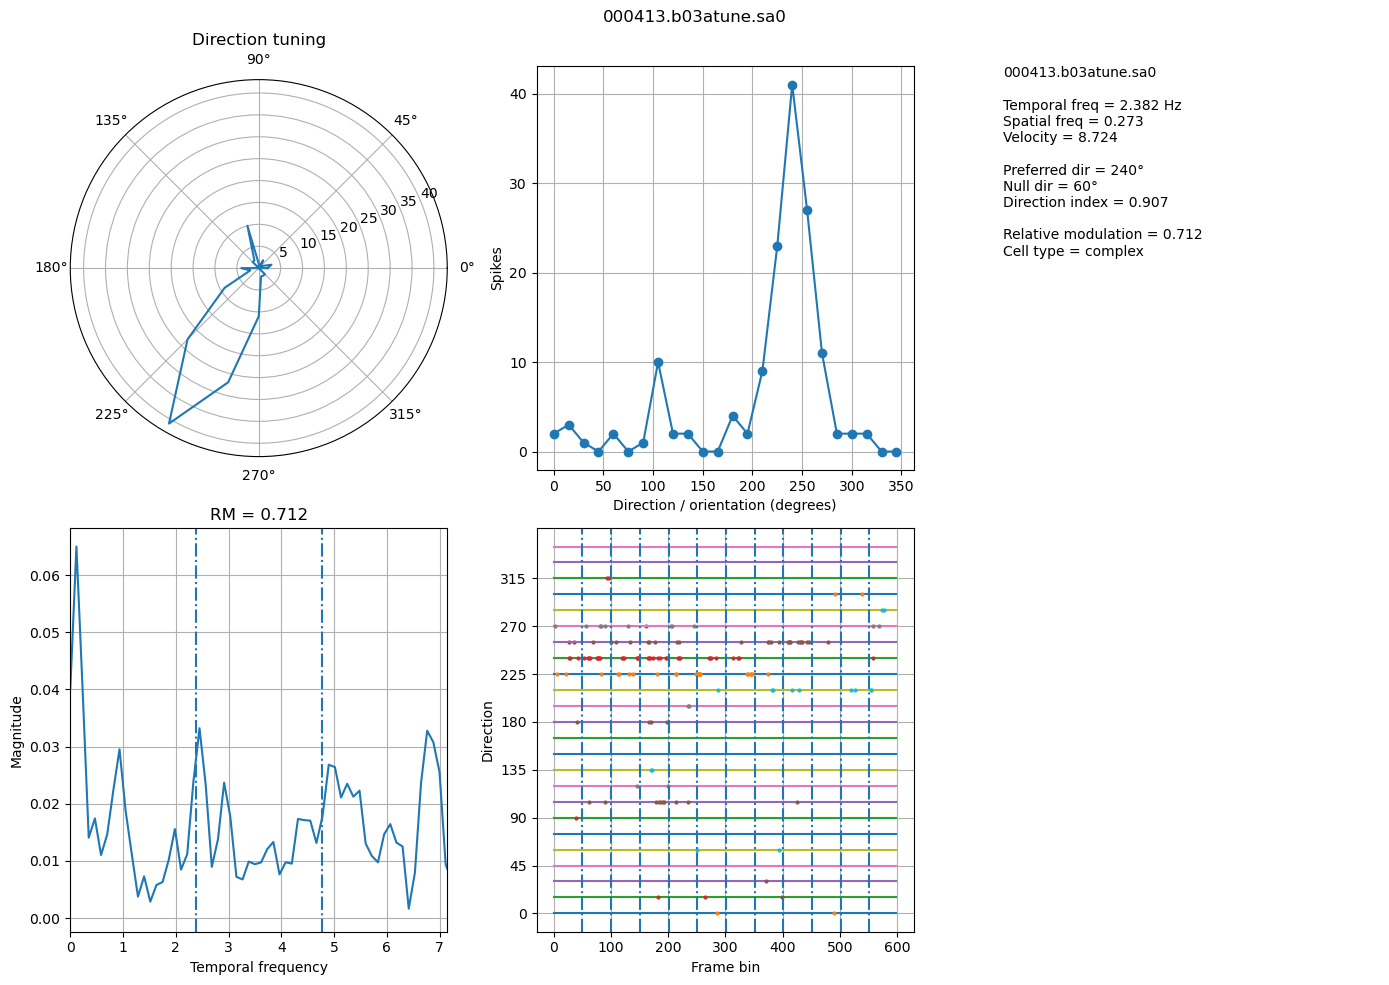

In [72]:
flog = retrieve_log(
    path=COMPLEX_NEURON_PATH,
    filename="000413.b03atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)

In [73]:

for path in paths_complex_trials:

    log_lines         = load_log_lines(path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)

    
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


### neuron b02 of 2004

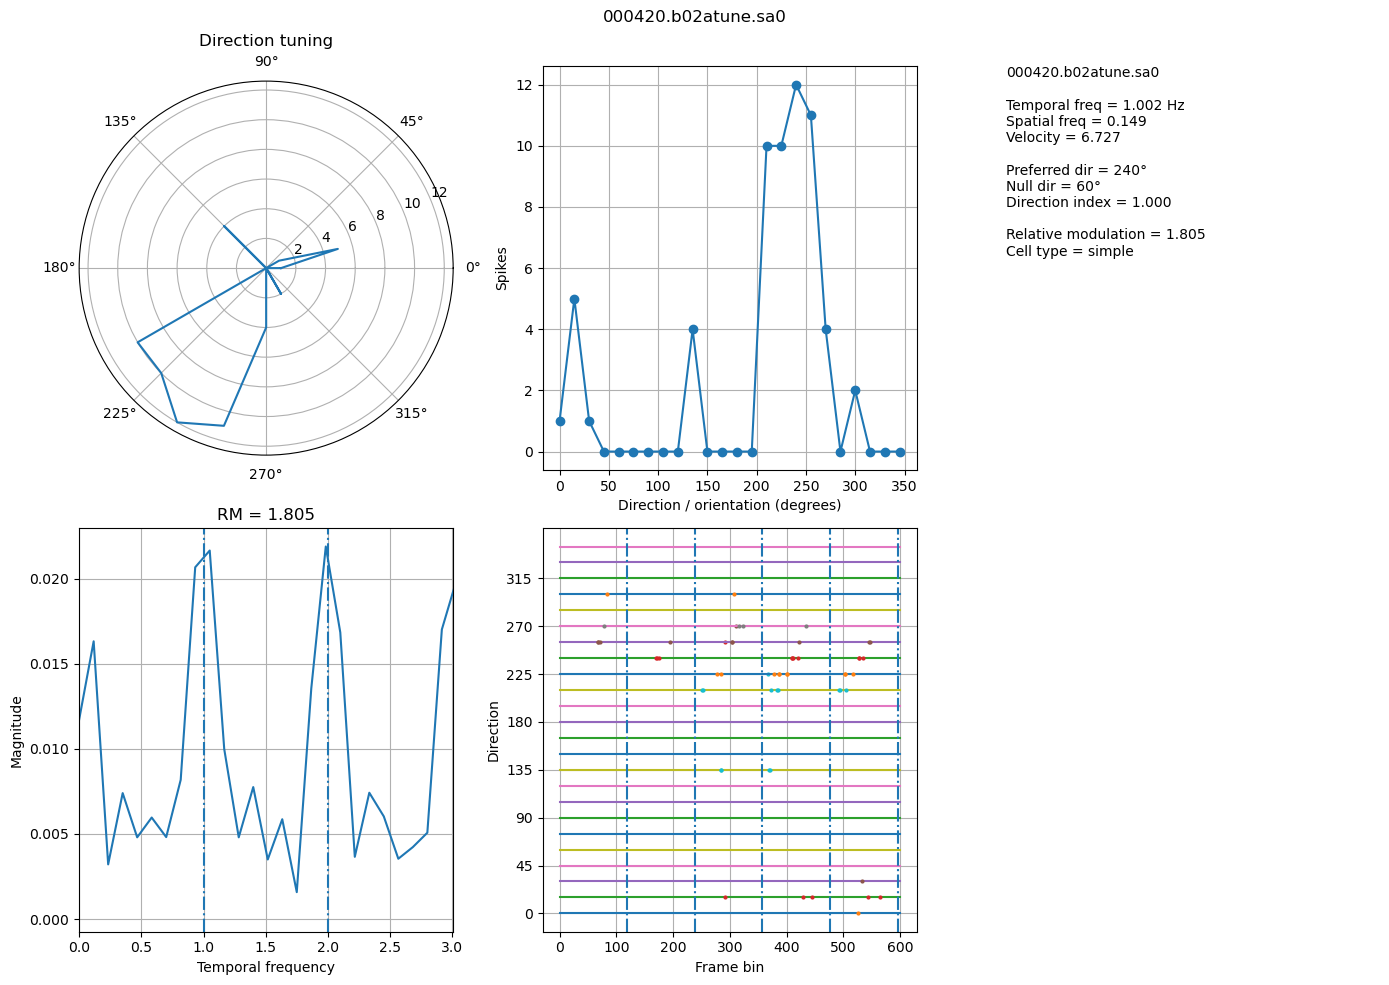

In [74]:
flog = retrieve_log(
    path=LINEAR_NEURON_PATH_2,
    filename="000420.b02atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)
paths = [LINEAR_NEURON_PATH_2 / name for name in filenames_linear_2]

msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1

In [75]:
for path in paths_linear_trial_2:


    msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1


    log_lines         = load_log_lines( path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


### Analysis of the stimulus and spike train data

- Each column in the left image contains the 16 bars shown at one instant in time, that is, at one stimulus frame. Since the frame rate is approximately 59.72 Hz, each frame lasts about 1/59.72≈0.0167 s, or 16.7 ms. 

- in the right image we can see the stimulus value for one frame 

- the bars are oriented in the preferred direction of the neuron found through the tuning curve

- the value of the bars is -1(dark), +1(bright)



stimulus shape:(32767, 16), stimulus mean=3.051850947599719e-05, stimulus varianc=0.9999999990686206


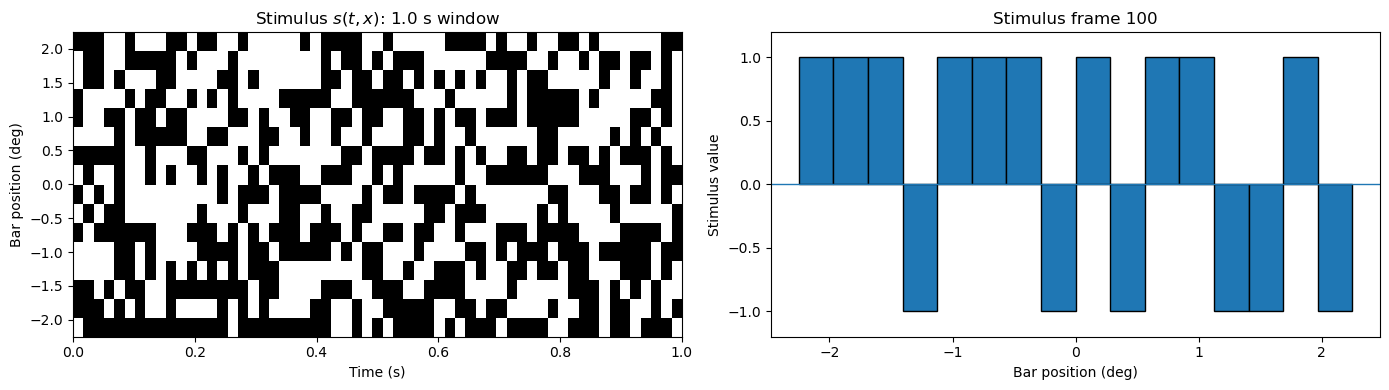

In [76]:
msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1
T, N = msq1D_stim.shape
mean_stim=msq1D_stim.mean()
stimulus_variance=np.var(msq1D_stim)

print(f'stimulus shape:{T,N}, stimulus mean={mean_stim}, stimulus varianc={stimulus_variance}')

T, N = msq1D_stim.shape

width_deg = 4.50
bar_width_deg = width_deg / N

bar_centers = (
    -width_deg / 2
    + bar_width_deg / 2
    + np.arange(N) * bar_width_deg
)


t0 = 0.0
duration = 1.0

i0 = int(t0 * frame_rate)
i1 = int((t0 + duration) * frame_rate)

stim_window = msq1D_stim[i0:i1]

# ---- right plot: one single frame ----
frame = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: stimulus over time
im = axes[0].imshow(
    stim_window.T,
    aspect="auto",
    cmap="gray",
    interpolation="nearest",
    vmin=-1,
    vmax=1,
    extent=[
        t0,
        t0 + duration,
        -width_deg / 2,
        width_deg / 2,
    ],
    origin="lower"
)

axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Bar position (deg)")
axes[0].set_title(f"Stimulus $s(t,x)$: {duration:.1f} s window")

axes[1].bar(
    bar_centers,
    msq1D_stim[frame],
    width=bar_width_deg,
    align="center",
    edgecolor="black"
)

axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel("Bar position (deg)")
axes[1].set_ylabel("Stimulus value")
axes[1].set_title(f"Stimulus frame {frame}")
axes[1].set_ylim(-1.2, 1.2)


plt.tight_layout()
plt.show()



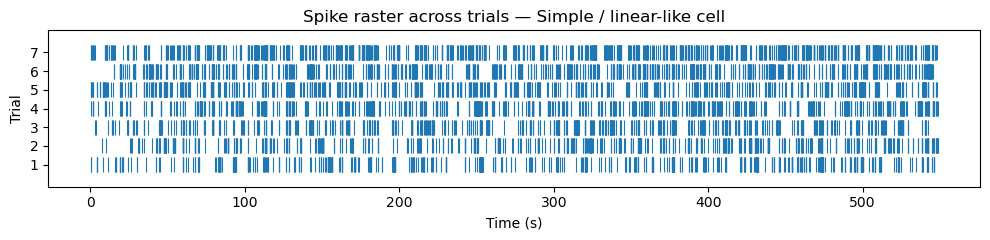

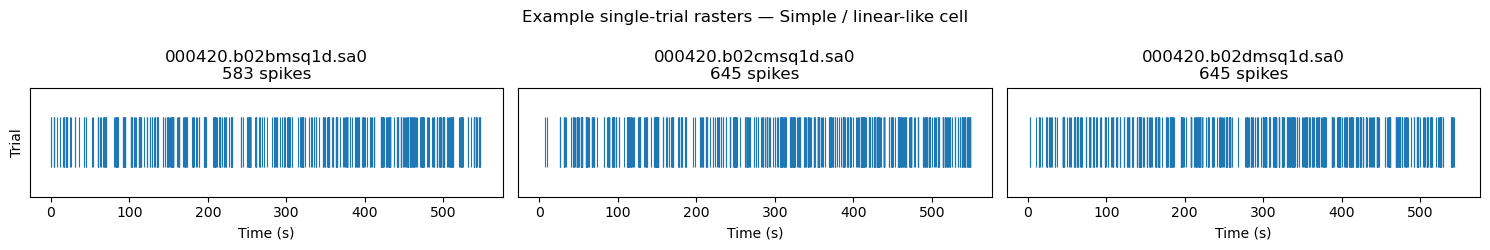

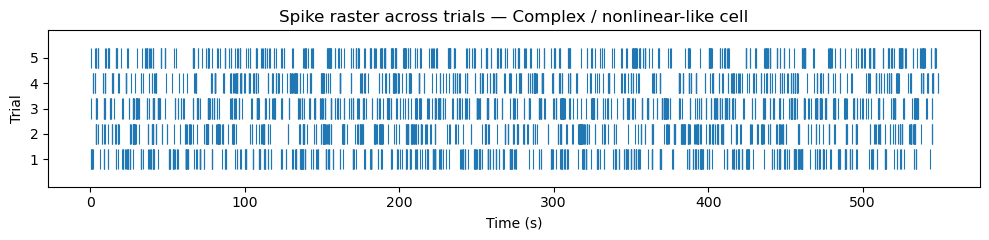

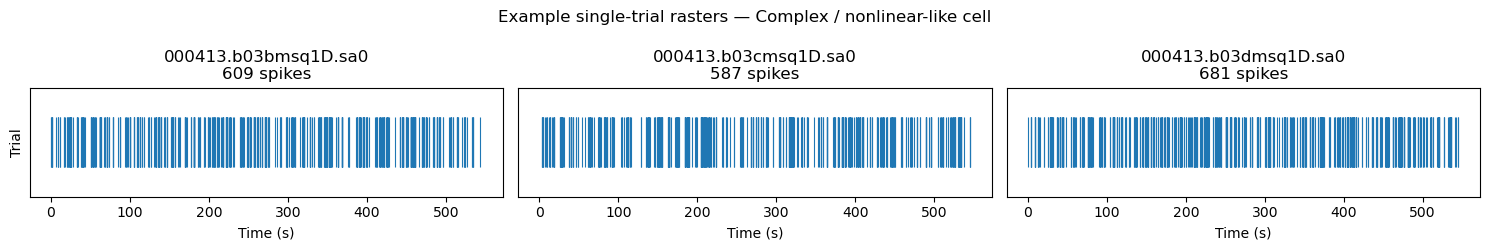

In [77]:
groups = {
    "Simple / linear-like cell": paths_linear_trial_2,
    "Complex / nonlinear-like cell": paths_complex_trials,
}

for group_name, paths in groups.items():

    # ---------- Full raster across all trials ----------
    plt.figure(figsize=(10, 2.5))

    for i, path in enumerate(paths):
        events, spk_sec, hdr = fget_spk_python(path)

        plt.eventplot(
            spk_sec,
            lineoffsets=i + 1,
            linelengths=0.8,
            linewidths=0.8
        )

    plt.xlabel("Time (s)")
    plt.ylabel("Trial")
    plt.yticks(range(1, len(paths) + 1))
    plt.title(f"Spike raster across trials — {group_name}")
    plt.tight_layout()
    plt.show()


    # ---------- First 3 trials next to each other ----------
    n_trials = min(3, len(paths))

    fig, axes = plt.subplots(
        1,
        n_trials,
        figsize=(5 * n_trials, 2.5),
        sharex=True,
        sharey=True
    )

    if n_trials == 1:
        axes = [axes]

    for ax, path in zip(axes, paths[:n_trials]):
        events, spike_times_sec, hdr = fget_spk_python(path)

        ax.eventplot(
            spike_times_sec,
            lineoffsets=1,
            linelengths=0.8,
            linewidths=0.8
        )

        ax.set_title(f"{Path(path).name}\n{len(events)} spikes")
        ax.set_xlabel("Time (s)")
        ax.set_yticks([])

    axes[0].set_ylabel("Trial")

    fig.suptitle(f"Example single-trial rasters — {group_name}")
    plt.tight_layout()
    plt.show()

### Spike-Triggered Average (STA)

The spike-triggered average (STA) for visual stimuli is defined as the average stimulus preceding a spike. 

To choose an appropriate lag window, we first computed the STA using a relatively large number of temporal lags. For each lag, we summarized the strength of the STA across the spatial dimension by computing the squared Euclidean norm


$E(\tau)=\sum_x \mathrm{STA}(\tau,x)^2$

This quantity measures the overall magnitude of the spike-triggered stimulus pattern at each time before the spike. We then plotted $\tau$ as a function of lag and also visualized the STA for different lag windows. This allowed us to inspect at which temporal lags the STA showed the clearest and most interpretable spatiotemporal structure.




Although the STA of the simple cell shows a somewhat clearer spatiotemporal structure, the difference between the simple and complex cells is not absolute. Both STAs contain visible patterns across bar position and temporal lag. However, the simple cell exhibits a stronger increase in STA norm close to the spike and a more coherent arrangement of positive and negative regions, suggesting a stronger linear receptive-field component. In contrast, the complex-cell STA appears less stable across lag windows and has a weaker overall STA norm. This is consistent with the simple/complex classification, but it also shows that the STA alone is not sufficient to sharply distinguish the two cell types. Rather, the STA provides only a first-order linear approximation of the stimulus-response relationship.



In [78]:
def compute_sta(spike_files, stim, n_lags, frame_rate):
    T, N        = stim.shape
    lag_offsets = np.arange(1, n_lags + 1)       # [1, 2, ..., n_lags]; row 0 = most recent
    sta_accum   = np.zeros((n_lags, N))
    n_total     = 0

    for path in spike_files:
        _, spk_sec, _ = fget_spk_python(path) 
        frames = np.floor(spk_sec * frame_rate).astype(int)
        valid  = (frames >= n_lags) & (frames < T)
        frames = frames[valid]

        windows    = frames[:, np.newaxis] - lag_offsets[np.newaxis, :]   # (n_spikes, n_lags)
        sta_accum += stim[windows].sum(axis=0)                            # (n_lags, N)
        n_total   += len(frames)
        

   
    return sta_accum / n_total, n_total


def compute_r_estimate(stim, kernel, r0=0.0):
    T, N = stim.shape
    n_lags, N_kernel = kernel.shape

    assert N == N_kernel

    r_est = np.full(T, np.nan)

    for t in range(n_lags, T):
        total = 0.0

        for lag in range(n_lags):
            stimulus_frame = stim[t - lag - 1]
            kernel_frame = kernel[lag]

            total += np.sum(stimulus_frame * kernel_frame)

        r_est[t] = r0 + total

    return r_est


def bin_spikes_to_frames(spike_times_sec, T, frame_rate):
     
    edges = np.arange(T + 1) / frame_rate
    counts, _ = np.histogram(spike_times_sec, bins=edges)
    return counts


def smooth_frame_counts(counts, frame_rate, sigma_sec=0.05):
    sigma_frames = sigma_sec * frame_rate
    return gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_frames,
        mode="constant"
    ) * frame_rate

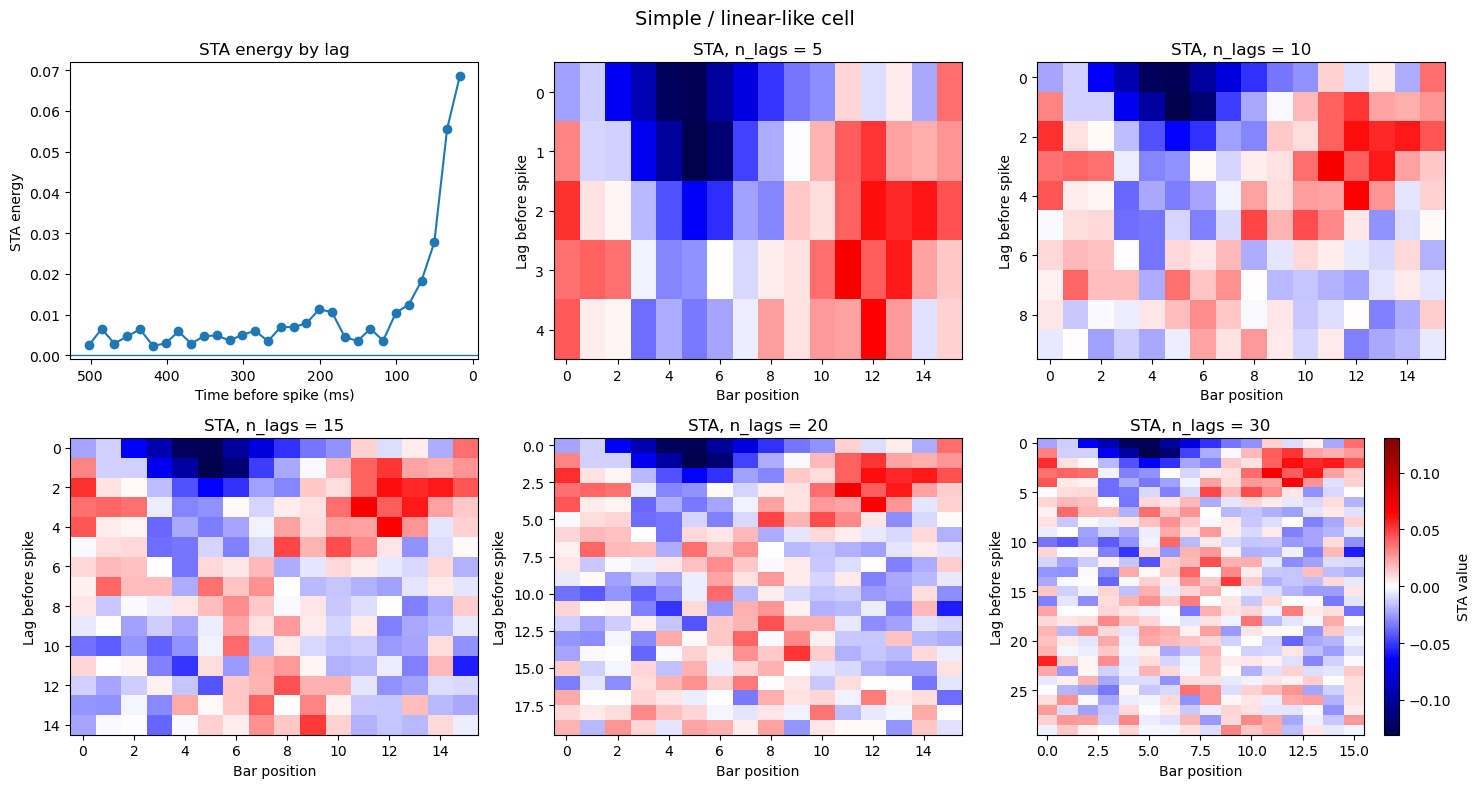

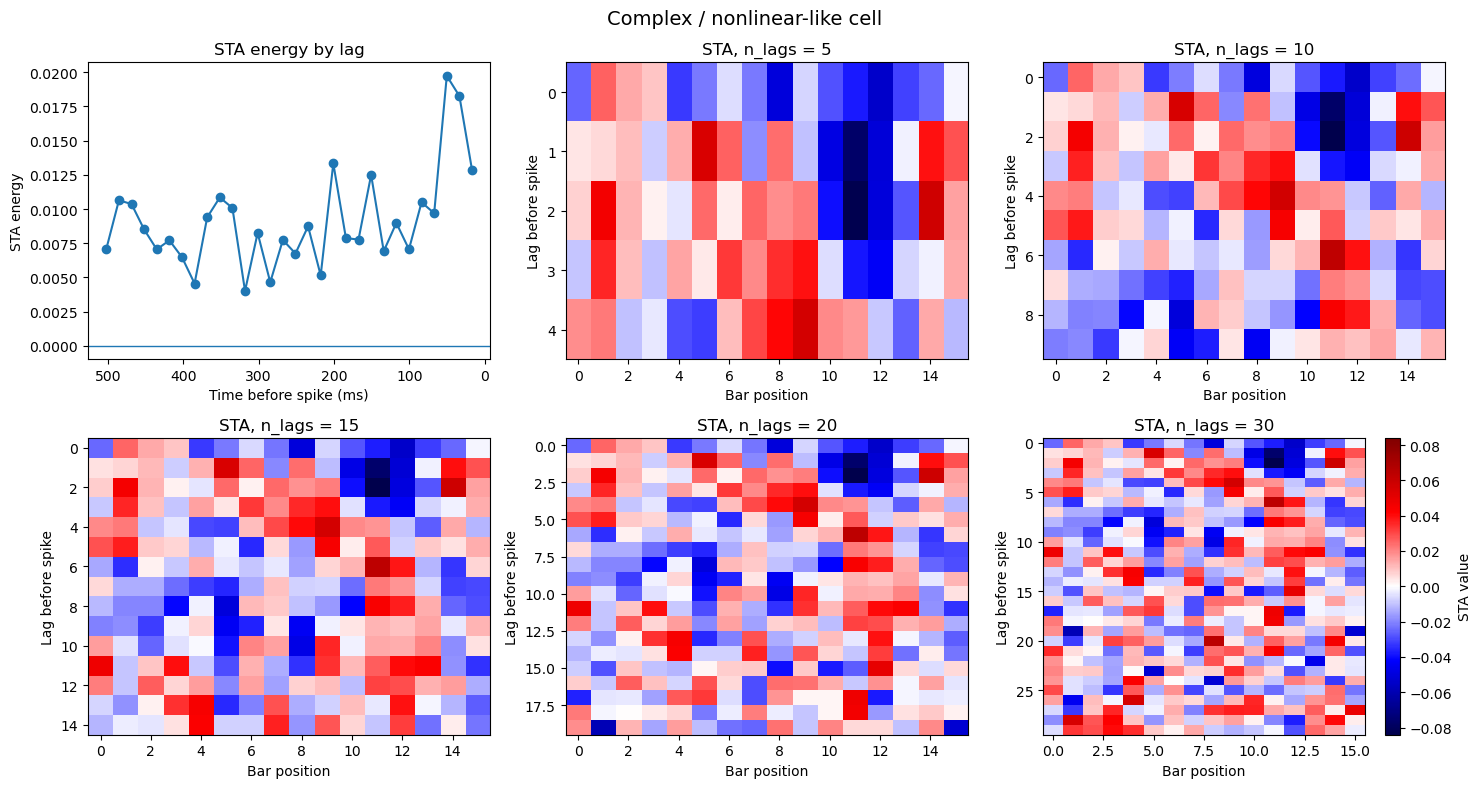

In [79]:
groups = {
    "Simple / linear-like cell": paths_linear_trial_2,
    "Complex / nonlinear-like cell": paths_complex_trials,
}

lag_values = [5, 10, 15, 20, 30]

all_stas = {}

for group_name, paths in groups.items():

    stas = {}

    # ---------- Compute STAs ----------
    for L in lag_values:
        sta_L, n_spikes = compute_sta(
            paths,
            msq1D_stim,
            n_lags=L,
            frame_rate=frame_rate
        )
        stas[L] = sta_L

    all_stas[group_name] = stas



    ############################################### plotting
    fig, axes = plt.subplots(
        2, 3,
        figsize=(15, 8),
        sharex=False
    )

    axes = axes.ravel()

    fig.suptitle(group_name, fontsize=14)

    # ---------- First panel: STA energy ----------
    sta_30 = stas[30]

    lag_ms = 1000 * np.arange(1, sta_30.shape[0] + 1) / frame_rate
    lag_energy = (np.sqrt(np.sum(sta_30**2, axis=1)))**2

    axes[0].plot(lag_ms, lag_energy, marker="o")
    axes[0].invert_xaxis()
    axes[0].axhline(0, linewidth=1)
    axes[0].set_title("STA energy by lag")
    axes[0].set_xlabel("Time before spike (ms)")
    axes[0].set_ylabel("STA energy")

    # ---------- Remaining five panels: STA heatmaps ----------
    vmax = max(np.max(np.abs(stas[L])) for L in lag_values)

    for ax, L in zip(axes[1:], lag_values):
        sta_L = stas[L]

        im = ax.imshow(
            sta_L,
            aspect="auto",
            cmap="seismic",
            vmin=-vmax,
            vmax=vmax,
            origin="upper"
        )

        ax.set_title(f"STA, n_lags = {L}")
        ax.set_xlabel("Bar position")
        ax.set_ylabel("Lag before spike")

    cbar = fig.colorbar(
        im,  
    )

    cbar.set_label("STA value")

    plt.tight_layout()
    plt.show()


    # TO CHANGE Lag before spike (frames) to Lag before spike (ms)??

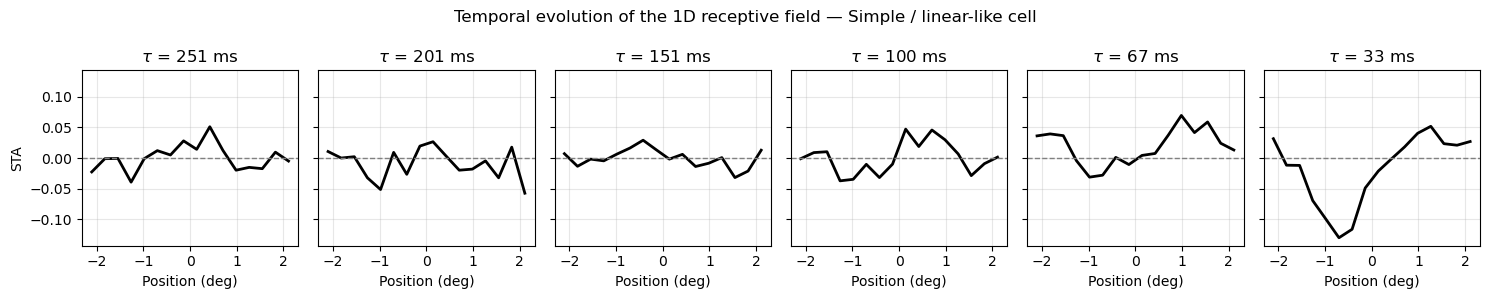

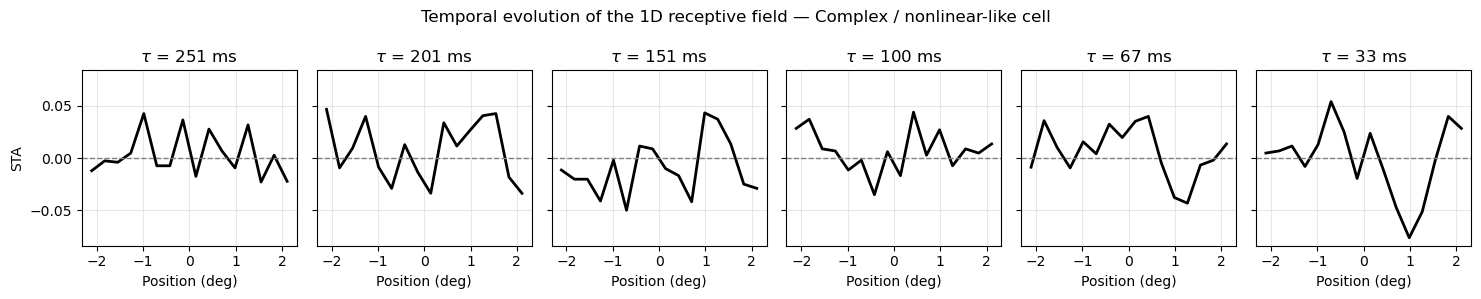

In [80]:
target_lags_ms = [250, 200, 150, 100, 75, 30]

groups_to_plot = [
    "Simple / linear-like cell",
    "Complex / nonlinear-like cell",
]

for group_name in groups_to_plot:

    sta_plot = all_stas[group_name][20]   # use the 20-lag STA

    n_lags, n_bars = sta_plot.shape

    lags_ms = 1000 * np.arange(1, n_lags + 1) / frame_rate

    lag_indices = [
        int(np.argmin(np.abs(lags_ms - target)))
        for target in target_lags_ms
    ]

    vmax = np.max(np.abs(sta_plot[lag_indices, :]))

    fig, axes = plt.subplots(
        1,
        len(lag_indices),
        figsize=(15, 3),
        sharey=True
    )

    for ax, lag_idx, target in zip(axes, lag_indices, target_lags_ms):
        profile = sta_plot[lag_idx, :]

        ax.plot(
            bar_centers,
            profile,
            color="black",
            linewidth=2
        )

        ax.axhline(
            0,
            color="gray",
            linestyle="--",
            linewidth=1
        )

        ax.set_ylim(-vmax * 1.1, vmax * 1.1)
        ax.set_title(rf"$\tau$ = {lags_ms[lag_idx]:.0f} ms")
        ax.set_xlabel("Position (deg)")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("STA")
    #$D(x,\tau)$ is proportional to STA

    fig.suptitle(f"Temporal evolution of the 1D receptive field — {group_name}")
    plt.tight_layout()
    plt.show()

using $10$ lags corresponds to approximately:


$10 \times 16.7 \approx 167 \text{ ms}$

of stimulus history before the spike. Based on the STA energy plot, this window captures the main part of the response while avoiding unnecessarily long, noisier lag windows.

#### Linearity sanity check of the STA filter
we applied the learned STA kernel to the original M-sequence segment and to its contrast-inverted version. The two predicted responses were perfectly anticorrelated, r=−1, as expected for a linear filter under contrast inversion.

In [81]:
imsq1D = loadmat(ISTIM_PATH)["imsq1D"].astype(float)

print(np.all(imsq1D == -msq1D_stim[:512]))
print(np.mean(imsq1D + msq1D_stim[:512]))

True
0.0


In [82]:
r_inv = compute_r_estimate(imsq1D, stas[10])
r_orig_512 = compute_r_estimate(msq1D_stim[:512], stas[10])

valid = np.isfinite(r_inv) & np.isfinite(r_orig_512)

print(np.corrcoef(r_inv[valid], r_orig_512[valid])[0, 1])

-0.9999999999999999


### Optimal Kernel Estimation

The theoretical relation between the optimal linear kernel and the spike-triggered average is $D(\tau, x) = \frac{\langle r \rangle}{\sigma_s^2} \mathrm{STA}(\tau, x)$

The stimulus variance is $\sigma_s^2 \approx 1.$ Thus, for this stimulus, $D(\tau, x)\approx\langle r \rangle \mathrm{STA}(\tau, x).$

So the optimal kernel has the same spatiotemporal structure as the STA, but it is scaled by the mean firing rate.

Now we'll compute r_estimate using the STA based linear kernel
check correlation between r_estimate (calculated with all the points but one)
and the smoothed firing rate gotten from the datapoint we left out

In [83]:
#ridefined
n_lags = 10 
n_trials = len(paths_linear_trial_2)

stim_duration = T / frame_rate
recording_duration = stim_duration * n_trials

Mean correlation: 0.05049450465904106
Std correlation: 0.008409306191594532


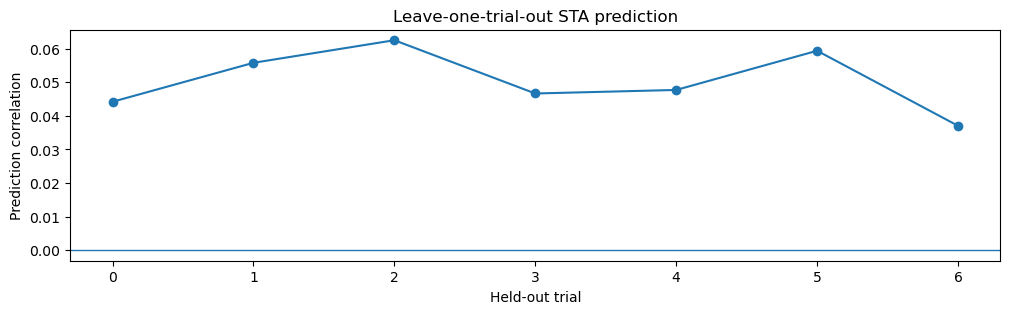

In [84]:
loo_corrs = []
loo_results=[]

for test_idx in range(len(paths_linear_trial_2,)):
    train_files = [f for i, f in enumerate(paths_linear_trial_2,) if i != test_idx]
    test_file = paths_linear_trial_2[test_idx]

    n_spikes_train_total = 0

    for path in train_files:
        events, spk_sec, hdr = fget_spk_python(path)
        valid_spikes = (spk_sec >= 0) & (spk_sec < stim_duration)
        n_spikes_train_total += valid_spikes.sum()

    recording_duration_train = len(train_files) * stim_duration
    mean_firing_rate = n_spikes_train_total / recording_duration_train
    



    sta_train, n_train = compute_sta(
        train_files,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate,
        
    )

    kernel_train = mean_firing_rate * sta_train / stimulus_variance

    r_est = compute_r_estimate(msq1D_stim, kernel_train, r0=mean_firing_rate)

    _, spk_sec_test, _ = fget_spk_python(test_file)

    spike_counts = bin_spikes_to_frames(
        spk_sec_test,
        T=T,
        frame_rate=frame_rate,
        
    )

    rate_test = smooth_frame_counts(
        spike_counts,
        frame_rate=frame_rate,
        sigma_sec=0.05
    )
    valid = np.isfinite(r_est) & np.isfinite(rate_test)
    x = r_est[valid]
    y = rate_test[valid]
    corr=np.corrcoef(x, y)[0, 1]
    
    loo_corrs.append(corr)
    
    loo_results.append({
        "test_idx": test_idx,
        "test_file": test_file,
        "r_est": r_est,
        "rate_test": rate_test,
        "spike_counts": spike_counts,
        "corr": corr,
    })

loo_corrs = np.array(loo_corrs)

print("Mean correlation:", np.nanmean(loo_corrs))
print("Std correlation:", np.nanstd(loo_corrs))


plt.figure(figsize=(12, 3))
plt.plot(loo_corrs, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Held-out trial")
plt.ylabel("Prediction correlation")
plt.title("Leave-one-trial-out STA prediction")
plt.show()

To visualize the relationship between the STA prediction and the held-out neural response, we binned time points according to the z-scored STA prediction and computed the mean observed firing rate within each bin. The observed response increases monotonically with the STA prediction, indicating that time points with stronger predicted linear drive tend to have higher firing rates. Although the frame-wise correlation is small (\(r = 0.070\)), the binned curve shows a clear positive relationship between the STA-based prediction and the held-out response.

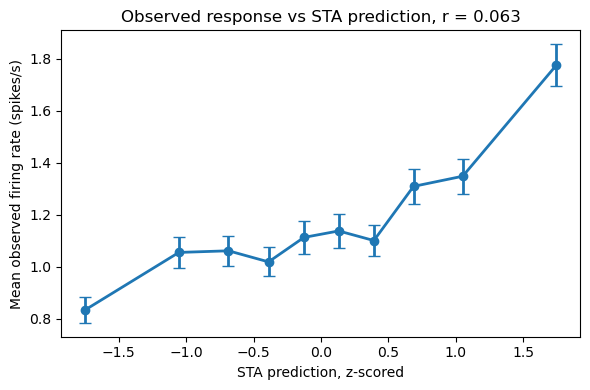

In [85]:
trial_to_plot = 2

res = loo_results[trial_to_plot]

r_est = res["r_est"]
rate_test = res["rate_test"]
corr = res["corr"]

valid = np.isfinite(r_est) & np.isfinite(rate_test)

x = r_est[valid]
y = rate_test[valid]

# z-score prediction for binning
x_z = (x - np.mean(x)) / np.std(x)

n_bins = 10
bins = np.quantile(x_z, np.linspace(0, 1, n_bins + 1))

bin_centers = []
mean_response = []
sem_response = []

for i in range(n_bins):
    in_bin = (x_z >= bins[i]) & (x_z <= bins[i + 1])

    bin_centers.append(np.mean(x_z[in_bin]))
    mean_response.append(np.mean(y[in_bin]))
    sem_response.append(np.std(y[in_bin]) / np.sqrt(np.sum(in_bin)))

bin_centers = np.array(bin_centers)
mean_response = np.array(mean_response)
sem_response = np.array(sem_response)

plt.figure(figsize=(6, 4))

plt.errorbar(
    bin_centers,
    mean_response,
    yerr=sem_response,
    marker="o",
    capsize=4,
    linewidth=2
)

plt.xlabel("STA prediction, z-scored")
plt.ylabel("Mean observed firing rate (spikes/s)")
plt.title(f"Observed response vs STA prediction, r = {corr:.3f}")

plt.tight_layout()
plt.show()

Next block clearly shows that the linear kernel is just a scaled STA

In [86]:
n_spikes_total = 0
for path in paths_linear_trial_2:
    events, spk_sec, hdr = fget_spk_python(path)
    valid_spikes = (spk_sec >= 0) & (spk_sec < stim_duration)
    n_spikes_total += valid_spikes.sum()


mean_firing_rate = n_spikes_total / recording_duration

sta_10 = all_stas["Simple / linear-like cell"][10]
kernel = mean_firing_rate * sta_10 / stimulus_variance

print("Total spikes:", n_spikes_total)
print("Mean firing rate:", mean_firing_rate)

Total spikes: 5641
Mean firing rate: 1.4687273345569802


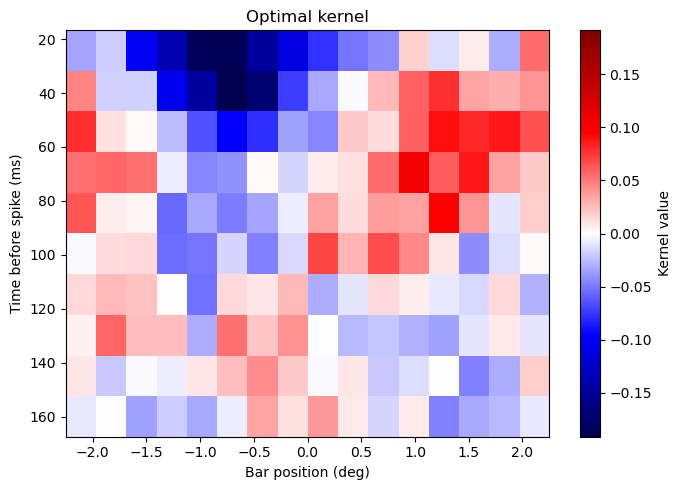

In [87]:
plt.figure(figsize=(7, 5))

vmax = np.max(np.abs(kernel))

#REDEFINE lag_ms 
lag_ms = 1000 * np.arange(1, sta_10.shape[0] + 1) / frame_rate

plt.imshow(
    kernel,
    aspect="auto",
    cmap="seismic",
    interpolation="nearest",
    vmin=-vmax,
    vmax=vmax,
    extent=[
        -width_deg / 2,
        width_deg / 2,
        lag_ms[-1],
        lag_ms[0],
    ],
    origin="upper"
)

plt.xlabel("Bar position (deg)")
plt.ylabel("Time before spike (ms)")
plt.title("Optimal kernel")
plt.colorbar(label="Kernel value")
plt.tight_layout()
plt.show()

### Spike-Trigerred Covariance (STC)

STC is a technique similar to the STA, but with a focus on the covariance and not the mean of the stimulus. Complex cells respond to a stimulus regardless of its position within the receptive field. Because of this, their receptive field can be estimated with a method that can recognize the same features regardless of their placement. 

The STC is computed by substracting the covariance matrix of the entire stimulus from the covariance matrix of selected stimuli instances that caused the neuron to fire. The eigenvectors of the resulting matrix correspond to different features, and the magnitude of eigenvalues represents the strength of each feature's effect on the firing rate.

In [88]:
def build_design_matrix(stim, n_lags):
    T, N = stim.shape
    lag_offsets = np.arange(1, n_lags + 1)
    t_idx = np.arange(n_lags, T)
    wins  = t_idx[:, np.newaxis] - lag_offsets[np.newaxis, :]
    return stim[wins].astype(np.float64).reshape(len(t_idx), n_lags * N)


def compute_stc(spike_files, stim, n_lags, frame_rate, X_flat, C_prior):
    T, N = stim.shape

    spk_wins = []
    for path in spike_files:
        _, spk_sec, _ = fget_spk_python(path)
        frames = np.floor(spk_sec * frame_rate).astype(int)
        frames = frames[(frames >= n_lags) & (frames < T)]
        spk_wins.append(X_flat[frames - n_lags])

    X_spk  = np.vstack(spk_wins)
    n_spk  = len(X_spk)
    C_spk  = (X_spk.T @ X_spk) / n_spk
    delta_C = C_spk - C_prior

    eigvals, eigvecs = np.linalg.eigh(delta_C)
    order      = np.argsort(np.abs(eigvals))[::-1]
    eigvals    = eigvals[order]
    eigvecs_2d = eigvecs[:, order].T.reshape(-1, n_lags, N)

    return eigvals, eigvecs_2d, n_spk

In [89]:
T, N_bars = msq1D_stim.shape
T_eff = T - n_lags

print('Building design matrix ...')
X_flat  = build_design_matrix(msq1D_stim, n_lags)
C_prior = (X_flat.T @ X_flat) / T_eff
print(f'  X_flat: {X_flat.shape}  ({X_flat.nbytes // 1024 // 1024} MB)')

print('\nSTC — complex cell ...')
eigvals_c, eigvecs_c, _ = compute_stc(paths_complex_trials, msq1D_stim, n_lags, frame_rate, X_flat, C_prior)
print('STC — simple cell ...')
eigvals_l, eigvecs_l, _ = compute_stc(paths_linear_trial_2,  msq1D_stim, n_lags, frame_rate, X_flat, C_prior)
print('done.')

Building design matrix ...
  X_flat: (32757, 160)  (39 MB)

STC — complex cell ...
STC — simple cell ...
done.


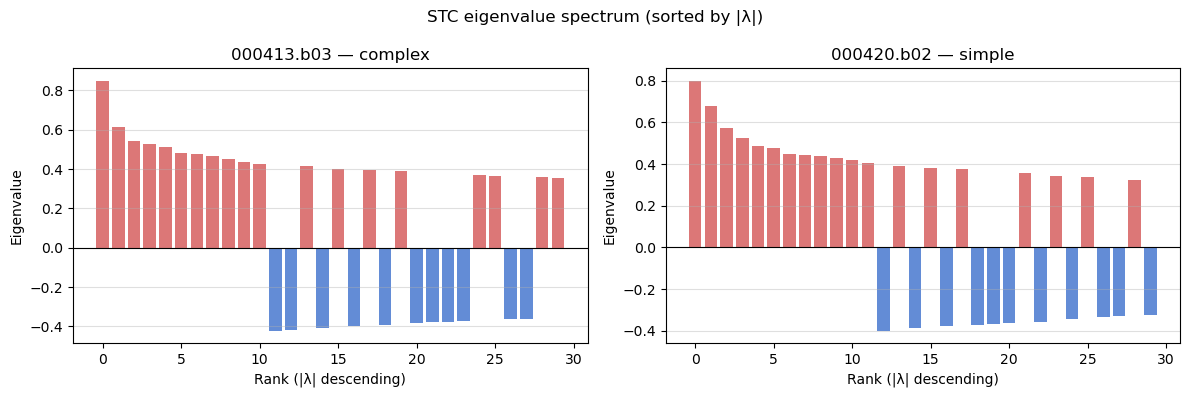

In [90]:
K_show = 30

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('STC eigenvalue spectrum (sorted by |λ|)')

for ax, eigvals, label in zip(
        axes,
        [eigvals_c, eigvals_l],
        ['000413.b03 — complex', '000420.b02 — simple']):
    idx    = np.arange(K_show)
    colors = ['#D65F5F' if v > 0 else '#4878CF' for v in eigvals[:K_show]]
    ax.bar(idx, eigvals[:K_show], color=colors, alpha=0.85)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_xlabel('Rank (|λ| descending)')
    ax.set_ylabel('Eigenvalue')
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

#### Comparing STA and STC using cross-validation and the R coefficient

=== Complex cell — 000413.b03 ===
  fold 0: STA r=0.0208   STC r=0.0388
  fold 1: STA r=0.0113   STC r=0.0437
  fold 2: STA r=0.0093   STC r=0.0426
  fold 3: STA r=0.0181   STC r=0.0216
  fold 4: STA r=0.0113   STC r=0.0360
STA r = 0.0142 ± 0.0045
STC r = 0.0365 ± 0.0079

=== Simple cell — 000420.b02 ===
  fold 0: STA r=0.0441   STC r=0.0600
  fold 1: STA r=0.0557   STC r=0.0589
  fold 2: STA r=0.0624   STC r=0.0840
  fold 3: STA r=0.0465   STC r=0.0592
  fold 4: STA r=0.0476   STC r=0.0629
  fold 5: STA r=0.0593   STC r=0.0557
  fold 6: STA r=0.0372   STC r=0.0592
STA r = 0.0504 ± 0.0083
STC r = 0.0628 ± 0.0089


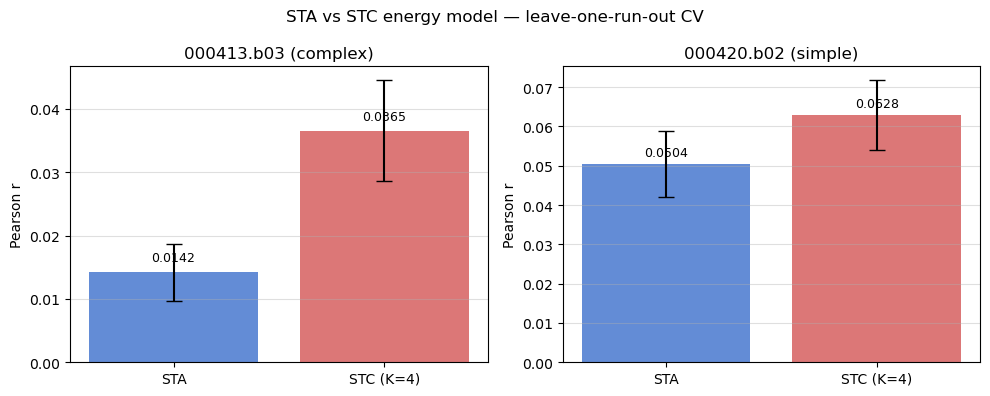

In [99]:
K_cv     = 4
sigma_sm = 3  # frames ≈ 50 ms at ~60 Hz


def cv_sta_stc(spike_files, stim, n_lags, frame_rate, X_flat, C_prior, K=4, sigma_smooth=3):
    T     = stim.shape[0]
    T_eff = X_flat.shape[0]
    n_runs = len(spike_files)

    run_ys = []
    for path in spike_files:
        _, spk_sec, _ = fget_spk_python(path)
        frames = np.floor(spk_sec * frame_rate).astype(int)
        frames = frames[(frames >= n_lags) & (frames < T)] - n_lags
        y = np.zeros(T_eff, dtype=np.float32)
        np.add.at(y, frames, 1)
        run_ys.append(y)
    run_ys    = np.stack(run_ys)
    run_rates = np.stack([gaussian_filter1d(y.astype(float), sigma_smooth) for y in run_ys])
    Xty       = np.stack([X_flat.T @ run_ys[i] for i in range(n_runs)])

    sta_rs, stc_rs = [], []

    for test_i in range(n_runs):
        train_idx = [i for i in range(n_runs) if i != test_i]

        # STA predictor (whitened for white noise → just STA / n_train_spikes)
        n_train = run_ys[train_idx].sum()
        w_sta   = Xty[train_idx].sum(axis=0) / (n_train + 1e-10)
        sta_rs.append(pearsonr(X_flat @ w_sta, run_rates[test_i]).statistic)

        # STC energy predictor
        spk_wins = []
        for i in train_idx:
            idx_spk = np.where(run_ys[i] > 0)[0]
            idx_spk = np.repeat(idx_spk, run_ys[i, idx_spk].astype(int))
            spk_wins.append(X_flat[idx_spk])
        X_spk_tr = np.vstack(spk_wins).astype(np.float64)

        C_sp    = (X_spk_tr.T @ X_spk_tr) / len(X_spk_tr)
        ev, evec = np.linalg.eigh(C_sp - C_prior)
        order   = np.argsort(np.abs(ev))[::-1]
        top_v   = evec[:, order[:K]]            # (D, K)

        energy  = (X_flat @ top_v) ** 2        # (T_eff, K)
        stc_rs.append(pearsonr(energy.sum(axis=1), run_rates[test_i]).statistic)

        print(f'  fold {test_i}: STA r={sta_rs[-1]:.4f}   STC r={stc_rs[-1]:.4f}')

    return np.array(sta_rs), np.array(stc_rs)


print('=== Complex cell — 000413.b03 ===')
sta_rs_c, stc_rs_c = cv_sta_stc(paths_complex_trials, msq1D_stim, n_lags, frame_rate,
                                 X_flat, C_prior, K=K_cv, sigma_smooth=sigma_sm)
print(f'STA r = {sta_rs_c.mean():.4f} ± {sta_rs_c.std():.4f}')
print(f'STC r = {stc_rs_c.mean():.4f} ± {stc_rs_c.std():.4f}')

print('\n=== Simple cell — 000420.b02 ===')
sta_rs_l, stc_rs_l = cv_sta_stc(paths_linear_trial_2, msq1D_stim, n_lags, frame_rate,
                                 X_flat, C_prior, K=K_cv, sigma_smooth=sigma_sm)
print(f'STA r = {sta_rs_l.mean():.4f} ± {sta_rs_l.std():.4f}')
print(f'STC r = {stc_rs_l.mean():.4f} ± {stc_rs_l.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('STA vs STC energy model — leave-one-run-out CV', fontsize=12)

for ax, (sta_rs, stc_rs), label in zip(
        axes,
        [(sta_rs_c, stc_rs_c), (sta_rs_l, stc_rs_l)],
        ['000413.b03 (complex)', '000420.b02 (simple)']):
    means = [sta_rs.mean(), stc_rs.mean()]
    stds  = [sta_rs.std(),  stc_rs.std()]
    bars  = ax.bar([f'STA', f'STC (K={K_cv})'], means, yerr=stds, capsize=6,
                   color=['#4878CF', '#D65F5F'], alpha=0.85)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, m + max(stds) * 0.15 + 1e-4,
                f'{m:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Pearson r')
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

The R coefficient quantifies correlation between two continuous variables. The quality of the STA/STC prediction can be evaluated by computing R between the true time-dependent firing rate, and the firing rate estimated by each model.

The improvement of the STC model over STA is more pronounced for the complex than the simple cell.

## Adding a static nonlinearity to the kernel (LN model)

The purely linear STA model predicts the firing rate as

$$r_{\mathrm{est}}(t) = r_0 + L(t), \qquad L(t) = \sum_{\tau,\,x} D(\tau, x)\, s(t-\tau, x)$$

where $L(t)$ is the linear drive: the optimal kernel $D(\tau, x)$ projected onto the recent stimulus history. This linear model has two problems:

1. it can predict negative firing rates, and
2. it assumes the response grows linearly with $L(t)$, whereas real neurons rectify and saturate.

We try to fix both by inserting a static nonlinearity $F$ between the linear filter and the predicted rate:

$$r_{\mathrm{est}}(t) = r_0 + F\big(L(t)\big)$$

This is the classic Linear–Nonlinear (LN) cascade. $F$ is static because it acts pointwise on $L(t)$ with no memory of its own — all the temporal structure stays in the kernel $D(\tau, x)$.

In [91]:
from scipy.ndimage import gaussian_filter1d


def observed_mean_rate(paths, T, frame_rate, sigma_sec=0.05):
    """Mean smoothed firing rate r(t) across trials (same stimulus replayed each trial)."""
    rates = []
    for path in paths:
        _, spk_sec, _ = fget_spk_python(path)
        counts = bin_spikes_to_frames(spk_sec, T=T, frame_rate=frame_rate)
        rates.append(
            smooth_frame_counts(counts, frame_rate=frame_rate, sigma_sec=sigma_sec)
        )
    return np.mean(rates, axis=0)


def fit_static_nonlinearity(L, r, n_bins=20, smooth_bins=1.0):
    """Empirical static nonlinearity F(L) = <r | L>.

    Bins the linear drive L into quantile bins, averages the measured rate r in
    each bin, lightly smooths the resulting curve, and returns a callable F that
    linearly interpolates between the bin centres.
    """
    valid = np.isfinite(L) & np.isfinite(r)
    L, r = L[valid], r[valid]

    edges   = np.quantile(L, np.linspace(0, 1, n_bins + 1))
    centers = np.full(n_bins, np.nan)
    means   = np.full(n_bins, np.nan)

    for i in range(n_bins):
        in_bin = (L >= edges[i]) & (L <= edges[i + 1])
        if in_bin.any():
            centers[i] = L[in_bin].mean()
            means[i]   = r[in_bin].mean()

    good = np.isfinite(centers) & np.isfinite(means)
    centers, means = centers[good], means[good]

    means_smooth = gaussian_filter1d(means, sigma=smooth_bins, mode="nearest")

    def F(x):
        return np.interp(x, centers, means_smooth)

    return F, centers, means, means_smooth

### Step 1: Measure the nonlinearity $F$

We compute the linear drive $L(t)$ by applying the optimal kernel to the stimulus without the baseline (`r0=0`). We then look at how the *measured* firing rate $r(t)$ depends on $L(t)$ by plotting $r(t)$ against $L(t)$. Binning $L(t)$ and averaging the measured rate inside each bin traces out the shape of $F$ empirically, and we fit a smooth curve through it.

Because $F$ is estimated as the mean observed rate given $L$, it already absorbs the baseline $r_0$, so from here on we use $r_{\mathrm{est}}(t) = F(L(t))$ (equivalently $r_0 = 0$).

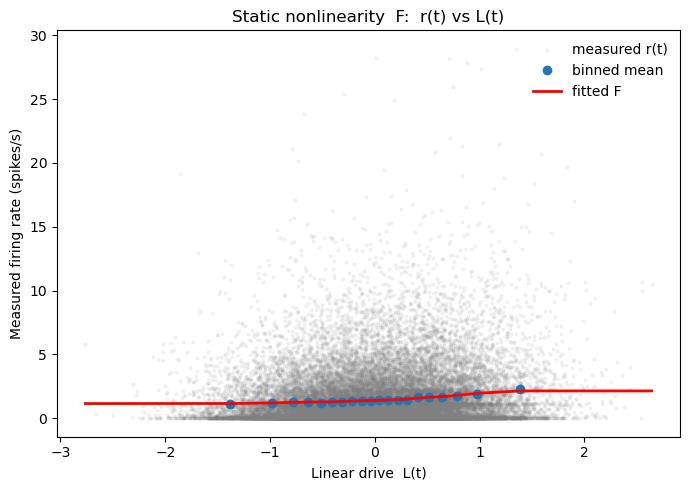

In [92]:
# Linear drive L(t): optimal kernel projected onto the stimulus history (no baseline)
L_full = compute_r_estimate(msq1D_stim, kernel, r0=0.0)

# Measured mean firing rate r(t) across all linear-cell trials
r_obs = observed_mean_rate(
    paths_linear_trial_2, T=T, frame_rate=frame_rate, sigma_sec=0.05
)

# Fit the static nonlinearity F
F, nl_centers, nl_means, nl_means_smooth = fit_static_nonlinearity(
    L_full, r_obs, n_bins=20
)

# plot: measured r(t) vs L(t) with the fitted curve F 
valid = np.isfinite(L_full) & np.isfinite(r_obs)

plt.figure(figsize=(7, 5))

plt.scatter(
    L_full[valid], r_obs[valid],
    s=4, alpha=0.08, color="gray", label="measured r(t)"
)

plt.plot(
    nl_centers, nl_means,
    "o", color="tab:blue", label="binned mean"
)

xx = np.linspace(np.nanmin(L_full), np.nanmax(L_full), 200)
plt.plot(xx, F(xx), color="red", linewidth=2, label="fitted F")

plt.xlabel("Linear drive  L(t)")
plt.ylabel("Measured firing rate (spikes/s)")
plt.title("Static nonlinearity  F:  r(t) vs L(t)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Step 2: Apply $F$ to obtain the LN prediction

We pass the linear drive through the fitted nonlinearity to get the new predicted rate $r_{\mathrm{est}}(t) = F(L(t))$. As a quick **in-sample** check we compare the frame-wise correlation with the observed rate for the linear model versus the LN model.

In [93]:
# LN prediction: r_est(t) = F(L(t))
r_est_LN = F(L_full)

# Linear prediction for reference: r_est(t) = r0 + L(t)
r_est_linear = compute_r_estimate(msq1D_stim, kernel, r0=mean_firing_rate)

valid = np.isfinite(L_full) & np.isfinite(r_obs)

corr_linear = np.corrcoef(r_est_linear[valid], r_obs[valid])[0, 1]
corr_LN     = np.corrcoef(r_est_LN[valid],     r_obs[valid])[0, 1]

print("In-sample frame-wise correlation with observed rate:")
print(f"  linear model : {corr_linear:.4f}")
print(f"  LN model     : {corr_LN:.4f}")

In-sample frame-wise correlation with observed rate:
  linear model : 0.1150
  LN model     : 0.1219


### Step 3: Leave-one-trial-out validation of the LN model

Exactly as for the linear model, but now we refit both the STA kernel and the nonlinearity $F$ on every trial but one, then measure the prediction correlation on the held-out trial. Since neither the kernel nor $F$ ever sees the held-out trial, this is an honest out-of-sample test. The linear LOO correlations (`loo_corrs`, computed earlier) are overlaid for comparison.

*(This cell recomputes the STA + linear drive for each fold, so it can take a little while to run.)*

LN  mean correlation: 0.05347687784307743
LN  std  correlation: 0.007987119573443831


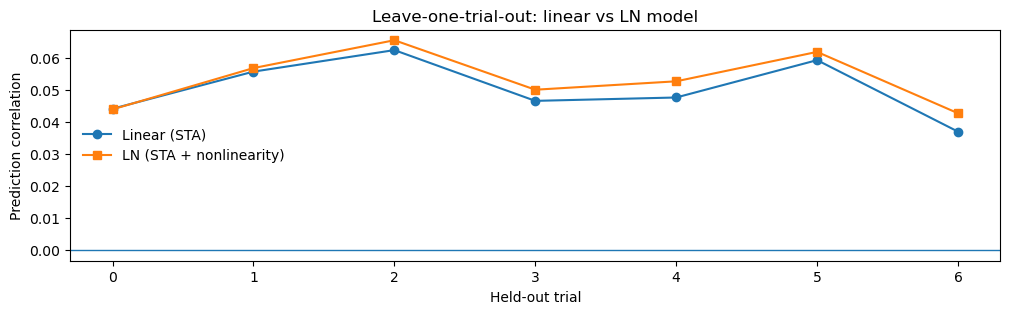

In [94]:
N_LAGS = kernel.shape[0]   # 10 lags, matching the optimal kernel above

loo_corrs_LN = []
loo_results_LN = []

for test_idx in range(len(paths_linear_trial_2)):
    train_files = [f for i, f in enumerate(paths_linear_trial_2) if i != test_idx]
    test_file   = paths_linear_trial_2[test_idx]

    # 1) linear filter (STA-based optimal kernel) from the training trials
    sta_train, _ = compute_sta(train_files, msq1D_stim, n_lags=N_LAGS, frame_rate=frame_rate)
    kernel_train = mean_firing_rate * sta_train / stimulus_variance

    # 2) linear drive (same stimulus -> same L for train and held-out trial)
    L_train = compute_r_estimate(msq1D_stim, kernel_train, r0=0.0)

    # 3) fit the nonlinearity F on the training rate only
    r_train = observed_mean_rate(train_files, T=T, frame_rate=frame_rate, sigma_sec=0.05)
    F_train, *_ = fit_static_nonlinearity(L_train, r_train, n_bins=20)

    # 4) LN prediction
    r_est_LN_test = F_train(L_train)

    # 5) held-out observed rate
    _, spk_sec_test, _ = fget_spk_python(test_file)
    counts_test = bin_spikes_to_frames(spk_sec_test, T=T, frame_rate=frame_rate)
    rate_test   = smooth_frame_counts(counts_test, frame_rate=frame_rate, sigma_sec=0.05)

    valid = np.isfinite(r_est_LN_test) & np.isfinite(rate_test)
    corr  = np.corrcoef(r_est_LN_test[valid], rate_test[valid])[0, 1]

    loo_corrs_LN.append(corr)
    loo_results_LN.append({
        "test_idx":  test_idx,
        "test_file": test_file,
        "r_est":     r_est_LN_test,
        "rate_test": rate_test,
        "F":         F_train,
        "corr":      corr,
    })

loo_corrs_LN = np.array(loo_corrs_LN)

print("LN  mean correlation:", np.nanmean(loo_corrs_LN))
print("LN  std  correlation:", np.nanstd(loo_corrs_LN))

plt.figure(figsize=(12, 3))
plt.plot(loo_corrs,    marker="o", label="Linear (STA)")
plt.plot(loo_corrs_LN, marker="s", label="LN (STA + nonlinearity)")
plt.axhline(0, linewidth=1)
plt.xlabel("Held-out trial")
plt.ylabel("Prediction correlation")
plt.title("Leave-one-trial-out: linear vs LN model")
plt.legend(frameon=False)
plt.show()

### Step 4: Predicted vs observed firing rate over time

Finally we compare the smoothed LN-predicted firing rate $F(L(t))$ with the observed mean firing rate across trials, in a representative time window. The purely linear prediction is shown faintly for reference.

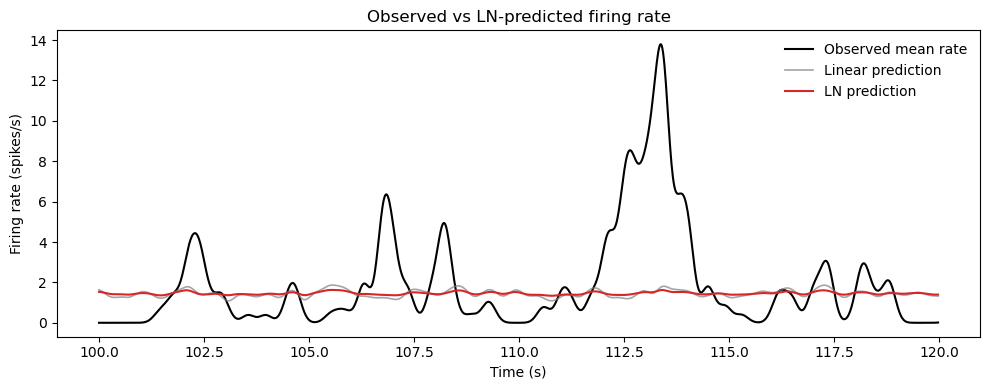

In [95]:
t0       = 100   # seconds
duration = 20    # seconds

i0 = int(t0 * frame_rate)
i1 = int((t0 + duration) * frame_rate)
t  = np.arange(T) / frame_rate

sigma_vis = 0.15   # 150 ms smoothing for visualisation

# observed mean rate across trials
r_obs_vis = observed_mean_rate(
    paths_linear_trial_2, T=T, frame_rate=frame_rate, sigma_sec=sigma_vis
)

# LN prediction, smoothed (fill the first NaN lags with the mean before smoothing)
r_est_LN_filled = np.nan_to_num(r_est_LN, nan=np.nanmean(r_est_LN))
r_est_LN_vis = gaussian_filter1d(
    r_est_LN_filled, sigma=sigma_vis * frame_rate, mode="constant"
)

# linear prediction, smoothed (for reference)
r_est_lin_filled = np.nan_to_num(r_est_linear, nan=np.nanmean(r_est_linear))
r_est_lin_vis = gaussian_filter1d(
    r_est_lin_filled, sigma=sigma_vis * frame_rate, mode="constant"
)

plt.figure(figsize=(10, 4))

plt.plot(t[i0:i1], r_obs_vis[i0:i1],     color="black",    linewidth=1.5, label="Observed mean rate")
plt.plot(t[i0:i1], r_est_lin_vis[i0:i1], color="tab:gray", linewidth=1.2, alpha=0.7, label="Linear prediction")
plt.plot(t[i0:i1], r_est_LN_vis[i0:i1],  color="tab:red",  linewidth=1.5, label="LN prediction")

plt.xlabel("Time (s)")
plt.ylabel("Firing rate (spikes/s)")
plt.title("Observed vs LN-predicted firing rate")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In other words, when your predictor is weak, the best static mapping is close to a constant. The honest LN prediction collapses toward the mean firing rate.

This is ass

### Final step: Quantifying the fit: correlation and variance explained

A compact summary of how well each model predicts the observed rate is the Pearson correlation $r$ between prediction and observation. Its square $r^2$ is the fraction of the response variance explained (the coefficient of determination after optimally rescaling the prediction):

$$r^2 = 1 - \frac{\mathrm{Var}\big(r_{\text{obs}} - a\,\hat r - b\big)}{\mathrm{Var}(r_{\text{obs}})}.$$

We report $r$ and $r^2$ for both the linear and the LN model over the full recording. The values are small ($r^2 \approx 1\!-\!2\%$), confirming quantitatively what the time-series plot shows: a single first-order STA kernel captures only a tiny part of this cell's response, even after adding the static nonlinearity.

In [96]:
# Correlation and variance explained (r^2) over the full recording.
# Reuses r_est_linear, r_est_LN and r_obs from the Step 1 / Step 2 cells above.
valid = np.isfinite(r_est_LN) & np.isfinite(r_est_linear) & np.isfinite(r_obs)

r_linear = np.corrcoef(r_est_linear[valid], r_obs[valid])[0, 1]
r_LN     = np.corrcoef(r_est_LN[valid],     r_obs[valid])[0, 1]

print("Full-recording fit to the observed mean firing rate:")
print(f"  linear model : r = {r_linear:.3f}   ->  r^2 = {100 * r_linear**2:5.2f}%  variance explained")
print(f"  LN model     : r = {r_LN:.3f}   ->  r^2 = {100 * r_LN**2:5.2f}%  variance explained")
print()
print(f"So the model accounts for ~{100 * r_LN**2:.1f}% of the response variance; "
      f"the remaining ~{100 * (1 - r_LN**2):.1f}% is unexplained by this first-order kernel.")

Full-recording fit to the observed mean firing rate:
  linear model : r = 0.115   ->  r^2 =  1.32%  variance explained
  LN model     : r = 0.122   ->  r^2 =  1.49%  variance explained

So the model accounts for ~1.5% of the response variance; the remaining ~98.5% is unexplained by this first-order kernel.


# 3. 2D

### Types of stimuli in the dataset

When describing properties of an image through its frequencies, there are two main components to consider, amplitude and phase.

Amplitude will affect the brightness/contrast of features at each level of detail, while phase will affect their placement.

White noise is defined as a signal with a flat power spectrum, i.e. equal amplitude for all frequencies.

In [100]:
def flatten_power_spectrum(image):
    """
    INPUT: square 2D array
    OUTPUT: the same array with a flattened power spectrum
    """
    # compute the fourier transform
    f_transform = np.fft.fft2(image)
    magnitude = np.abs(f_transform)
    magnitude[magnitude == 0] = 1e-8 # prevents division by 0
    # normalize the amplitudes
    f_flattened = f_transform / magnitude
    # return to space domain
    reconstructed = np.real(np.fft.ifft2(f_flattened))

    return reconstructed

def scramble_phase(image):
    """
    INPUT: square 2D array
    OUTPUT: the same array with a randomized phase spectrum
    """
    # compute the fourier transform
    f_transform = np.fft.fft2(image)
    magnitude = np.abs(f_transform)
    # generate random phases
    random_phase = np.random.uniform(-np.pi, np.pi, f_transform.shape)
    
    # combine original magnitude with random phase
    f_randomized = magnitude * np.exp(1j * random_phase)
    
    # return to space domain
    reconstructed = np.real(np.fft.ifft2(f_randomized))

    return reconstructed

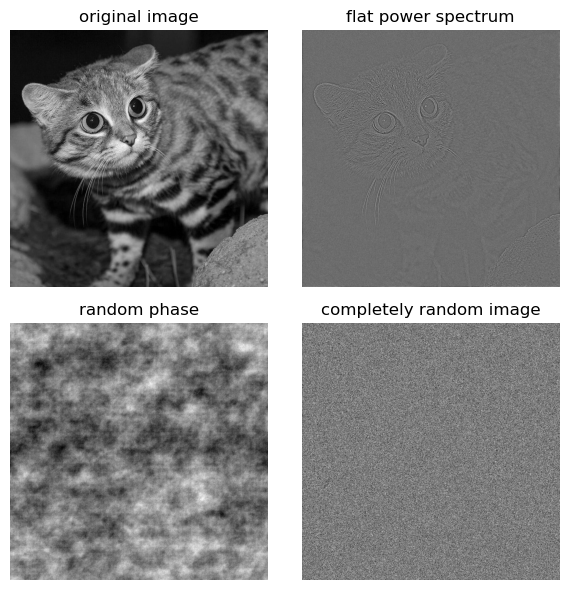

In [103]:
image = plt.imread("example_image.jpg")
# transform to grayscale
image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(6, 6))
ax1.imshow(image, cmap="gray")
ax1.set_title("original image")
ax1.axis("off")
ax2.imshow(flatten_power_spectrum(image), cmap="gray")
ax2.set_title("flat power spectrum")
ax2.axis("off")
ax3.imshow(scramble_phase(image), cmap="gray")
ax3.set_title("random phase")
ax3.axis("off")
ax4.imshow(flatten_power_spectrum(scramble_phase(image)), cmap="gray")
ax4.set_title("completely random image")
ax4.axis("off")
fig.tight_layout()

Even without amplitude information, a natural image is still recognizable.

Without phase  information, it becomes meaningless.

The image with randomized phase is different from white noise. In particular its power spectrum is not flat, it is identical to the original natural image.

In the experiment, stimulus images that allowed for best computation of STA were flattened natural images (top right). 

We know that the visual processing system is specifically tuned to the statisical characteristics of natural images. Those properties are extremely unlikely to occur in completely random images.

### Comparison of firing rates for different stimulus types

In [106]:
# file paths for the same cell, different stimuli
natural = r"..\data\crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\040812.A.c01\040812.A.c01cequalpower_C1.sa0"

flattened = r"..\data\crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\040812.A.c01\040812.A.c01ewhitenednatural_B1.sa0"

random_phase = r"..\data\crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\040812.A.c01\040812.A.c01irandomphase_A1.sa0"

# time unit of 0.1ms allows for integers instead of floats, offset skips the headers
natural = np.fromfile(natural, dtype=np.int32, offset=828)
flattened = np.fromfile(flattened, dtype=np.int32, offset=828)
random_phase = np.fromfile(random_phase, dtype=np.int32, offset=828)

# extracted from the stimulus file, timepoint (in 0.1ms) when the movie stops playing
end_time = 10040000

In [107]:
def gaussian_rate_convolution(spike_times, t_start=None, t_end=None, dt=0.001, sigma=0.2):
    """
    Gaussian-smoothed firing rate using binning + convolution.

    spike_times : spike times in seconds
    dt          : bin width in seconds
    sigma       : Gaussian std in seconds

    returns:
        t        : time axis
        rate     : firing rate in spikes/s
        counts   : binned spike counts
    """
    spike_times = np.asarray(spike_times)

    if t_start is None:
        t_start = spike_times[0]
    if t_end is None:
        t_end = spike_times[-1]

    bins = np.arange(t_start, t_end + dt, dt)
    counts, edges = np.histogram(spike_times, bins=bins)

    # Convert sigma from seconds to bins
    sigma_bins = sigma / dt

    # Smooth spike counts
    smoothed_counts = gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_bins,
        mode="constant"
    )

    # Convert counts/bin to spikes/second
    rate = smoothed_counts / dt

    # Bin centers
    t = edges[:-1] + dt / 2

    return t, rate, counts

In [108]:
t, r_n, _ = gaussian_rate_convolution(natural/10000, 0, end_time/10000, 0.04, 1)
_, r_f, _ = gaussian_rate_convolution(flattened/10000, 0, end_time/10000, 0.04, 1)
_, r_r, _ = gaussian_rate_convolution(random_phase/10000, 0, end_time/10000, 0.04, 1)

Text(0.5, 1.0, 'firing rates for different stimuli')

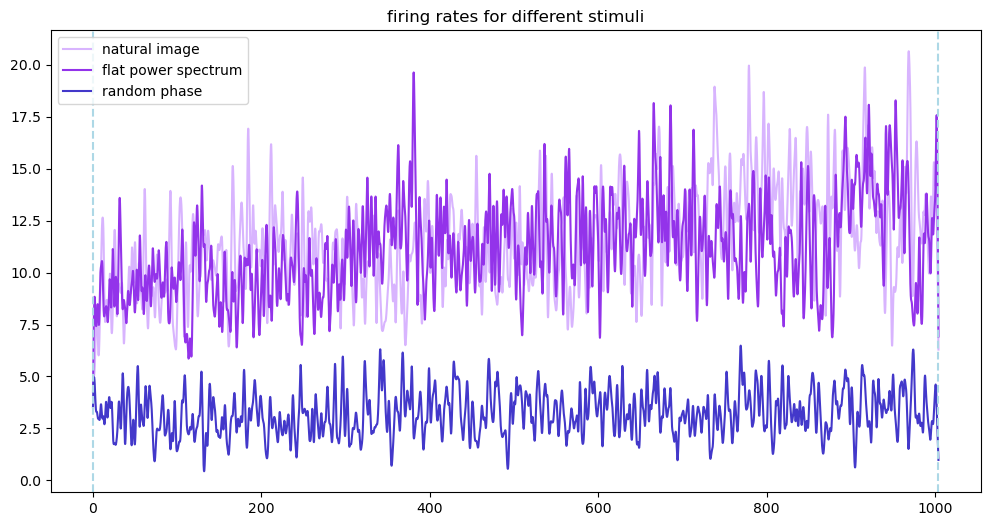

In [109]:
plt.figure(figsize=(12, 6))
plt.plot(t, r_n, label="natural image", color="#D8B4FE")
plt.plot(t, r_f, label="flat power spectrum", color="#9333EA")
plt.plot(t, r_r, label="random phase", color="#4338CA")
plt.axvline(0, color="lightblue", linestyle='--')
plt.axvline(1004, color="lightblue", linestyle='--')
plt.legend(loc="upper left")
plt.title("firing rates for different stimuli")

The firing rate in response to random phase stimulus is significantly lower than for both natural and "whitened natural" images. It also has less variability around its mean.

STA on the whitened stimulus